<a href="https://colab.research.google.com/github/DavidCM28/Proyecto_MachineLearning/blob/main/Notebook_Completo/analisis_problema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 2. Separación de variables

In [ ]:
import pandas as pd

datos = pd.read_csv("/content/data/alumnos.csv")

datos.head()

,Promedio_Parcial,Asistencia,Horas_Estudio,Accesos_Moodle,Tareas,Calificacion_Final,Resultado
0,92,81,6.2,40,9,90,Aprueba
1,56,100,12.4,30,7,78,Aprueba
2,57,78,3.4,23,7,67,Reprueba
3,52,83,6.4,35,7,73,Aprueba
4,87,85,9.3,33,10,96,Aprueba


In [ ]:
variables_entrada = [
    "Promedio_Parcial",
    "Asistencia",
    "Horas_Estudio",
    "Accesos_Moodle",
    "Tareas"
]

X_clasificacion = datos[variables_entrada]
y_clasificacion = datos["Resultado"]

X_regresion = datos[variables_entrada]
y_regresion = datos["Calificacion_Final"]

In [ ]:
print("Entradas para clasificación:")
display(X_clasificacion.head())

print("Objetivo de clasificación:")
display(y_clasificacion.head())

print("Entradas para regresión:")
display(X_regresion.head())

print("Objetivo de regresión:")
display(y_regresion.head())

Entradas para clasificación:


,Promedio_Parcial,Asistencia,Horas_Estudio,Accesos_Moodle,Tareas
0,92,81,6.2,40,9
1,56,100,12.4,30,7
2,57,78,3.4,23,7
3,52,83,6.4,35,7
4,87,85,9.3,33,10


Objetivo de clasificación:


,Resultado
0,Aprueba
1,Aprueba
2,Reprueba
3,Aprueba
4,Aprueba


Entradas para regresión:


,Promedio_Parcial,Asistencia,Horas_Estudio,Accesos_Moodle,Tareas
0,92,81,6.2,40,9
1,56,100,12.4,30,7
2,57,78,3.4,23,7
3,52,83,6.4,35,7
4,87,85,9.3,33,10


Objetivo de regresión:


,Calificacion_Final
0,90
1,78
2,67
3,73
4,96


# Fase 4. Implementación de los modelos

---




In [ ]:
# 1. Importar librerías adicionales

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [ ]:
# Transformar Resultado

In [ ]:
y_clasificacion_numerica = datos["Resultado"].map({
    "Aprueba": 1,
    "Reprueba": 0
})

print(y_clasificacion_numerica.value_counts())

Resultado
1    120
0     80
Name: count, dtype: int64


In [ ]:
# Dividir los datos

In [ ]:
X_train_clasificacion, X_test_clasificacion, y_train_clasificacion, y_test_clasificacion = train_test_split(
    X_clasificacion,
    y_clasificacion_numerica,
    test_size=0.20,
    random_state=42,
    stratify=y_clasificacion_numerica
)

X_train_regresion, X_test_regresion, y_train_regresion, y_test_regresion = train_test_split(
    X_regresion,
    y_regresion,
    test_size=0.20,
    random_state=42
)

print("Clasificación:")
print("Entrenamiento:", X_train_clasificacion.shape)
print("Prueba:", X_test_clasificacion.shape)

print("\nRegresión:")
print("Entrenamiento:", X_train_regresion.shape)
print("Prueba:", X_test_regresion.shape)

Clasificación:
Entrenamiento: (160, 5)
Prueba: (40, 5)

Regresión:
Entrenamiento: (160, 5)
Prueba: (40, 5)


In [ ]:
# Entrenar clasificación

In [ ]:
modelo_logistico = LogisticRegression(max_iter=1000)

modelo_arbol_clasificacion = DecisionTreeClassifier(
    random_state=42
)

modelo_random_forest_clasificacion = RandomForestClassifier(
    random_state=42
)

modelo_logistico.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

modelo_arbol_clasificacion.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

modelo_random_forest_clasificacion.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

print("Modelos de clasificación entrenados correctamente.")

Modelos de clasificación entrenados correctamente.


In [ ]:
# Entrenar regresión

In [ ]:
modelo_lineal = LinearRegression()

modelo_arbol_regresion = DecisionTreeRegressor(
    random_state=42
)

modelo_random_forest_regresion = RandomForestRegressor(
    random_state=42
)

modelo_lineal.fit(
    X_train_regresion,
    y_train_regresion
)

modelo_arbol_regresion.fit(
    X_train_regresion,
    y_train_regresion
)

modelo_random_forest_regresion.fit(
    X_train_regresion,
    y_train_regresion
)

print("Modelos de regresión entrenados correctamente.")

Modelos de regresión entrenados correctamente.


In [ ]:
# Generar predicciones

In [ ]:
pred_logistico = modelo_logistico.predict(X_test_clasificacion)

pred_arbol_clasificacion = modelo_arbol_clasificacion.predict(
    X_test_clasificacion
)

pred_random_forest_clasificacion = modelo_random_forest_clasificacion.predict(
    X_test_clasificacion
)

pred_lineal = modelo_lineal.predict(X_test_regresion)

pred_arbol_regresion = modelo_arbol_regresion.predict(
    X_test_regresion
)

pred_random_forest_regresion = modelo_random_forest_regresion.predict(
    X_test_regresion
)

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


In [ ]:
# Mostrar ejemplos

In [ ]:
comparacion_clasificacion = pd.DataFrame({
    "Resultado_real": y_test_clasificacion.values,
    "Regresion_Logistica": pred_logistico,
    "Arbol_Decision": pred_arbol_clasificacion,
    "Random_Forest": pred_random_forest_clasificacion
})

display(comparacion_clasificacion.head(10))

,Resultado_real,Regresion_Logistica,Arbol_Decision,Random_Forest
0,0,0,0,0
1,1,1,1,1
2,1,1,0,0
3,1,1,1,1
4,0,0,0,0
5,0,0,0,0
6,1,1,1,1
7,1,1,1,1
8,0,0,0,0
9,0,0,0,0


In [ ]:
comparacion_regresion = pd.DataFrame({
    "Calificacion_real": y_test_regresion.values,
    "Regresion_Lineal": pred_lineal.round(2),
    "Arbol_Decision": pred_arbol_regresion.round(2),
    "Random_Forest": pred_random_forest_regresion.round(2)
})

display(comparacion_regresion.head(10))

,Calificacion_real,Regresion_Lineal,Arbol_Decision,Random_Forest
0,44,41.26,36.0,40.35
1,81,77.51,80.0,73.21
2,88,87.35,92.0,89.89
3,64,61.13,58.0,60.95
4,81,82.70,79.0,82.36
5,40,39.35,36.0,39.71
6,98,97.67,94.0,94.94
7,89,91.30,84.0,88.39
8,71,68.24,71.0,66.70
9,60,68.96,69.0,67.23


# Fase 5. Evaluación de los modelos

In [ ]:
# Importar las métricas

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# Calcular métricas de clasificación

In [ ]:
resultados_clasificacion = []

modelos_clasificacion = {
    "Regresión Logística": pred_logistico,
    "Árbol de Decisión": pred_arbol_clasificacion,
    "Random Forest": pred_random_forest_clasificacion
}

for nombre, predicciones in modelos_clasificacion.items():
    accuracy = accuracy_score(y_test_clasificacion, predicciones)
    precision = precision_score(y_test_clasificacion, predicciones)
    recall = recall_score(y_test_clasificacion, predicciones)
    f1 = f1_score(y_test_clasificacion, predicciones)

    resultados_clasificacion.append({
        "Algoritmo": nombre,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

tabla_clasificacion = pd.DataFrame(resultados_clasificacion)

tabla_clasificacion[
    ["Accuracy", "Precision", "Recall", "F1-score"]
] = tabla_clasificacion[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

display(tabla_clasificacion)

,Algoritmo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.925,0.9565,0.9167,0.9362
1,Árbol de Decisión,0.900,1.0000,0.8333,0.9091
2,Random Forest,0.900,0.9545,0.8750,0.9130


In [ ]:
# Identificar el mejor modelo de clasificación

In [ ]:
mejor_clasificacion = tabla_clasificacion.loc[
    tabla_clasificacion["F1-score"].idxmax()
]

print("Mejor modelo de clasificación según F1-score:")
display(mejor_clasificacion.to_frame().T)

Mejor modelo de clasificación según F1-score:


,Algoritmo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.925,0.9565,0.9167,0.9362


In [ ]:
# Mostrar matrices de confusión

In [ ]:
for nombre, predicciones in modelos_clasificacion.items():
    matriz = confusion_matrix(
        y_test_clasificacion,
        predicciones
    )

    print(f"Matriz de confusión - {nombre}")
    print(matriz)
    print()

Matriz de confusión - Regresión Logística
[[15  1]
 [ 2 22]]

Matriz de confusión - Árbol de Decisión
[[16  0]
 [ 4 20]]

Matriz de confusión - Random Forest
[[15  1]
 [ 3 21]]



In [ ]:
# Graficar la matriz del mejor modelo

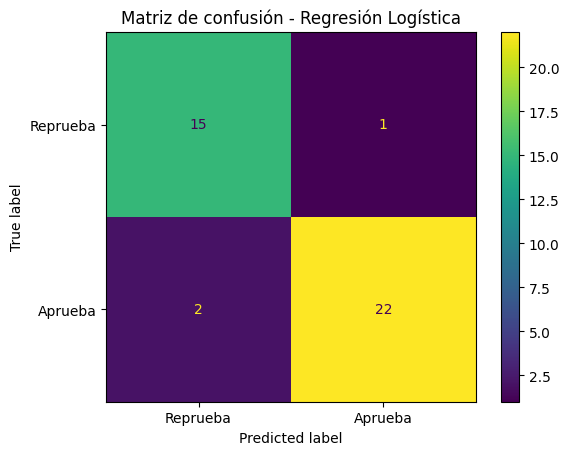

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

nombre_mejor_clasificacion = mejor_clasificacion["Algoritmo"]

predicciones_mejor_clasificacion = modelos_clasificacion[
    nombre_mejor_clasificacion
]

ConfusionMatrixDisplay.from_predictions(
    y_test_clasificacion,
    predicciones_mejor_clasificacion,
    display_labels=["Reprueba", "Aprueba"]
)

plt.title(
    f"Matriz de confusión - {nombre_mejor_clasificacion}"
)

plt.show()

In [ ]:
# Calcular métricas de regresión

In [ ]:
resultados_regresion = []

modelos_regresion = {
    "Regresión Lineal": pred_lineal,
    "Árbol de Decisión": pred_arbol_regresion,
    "Random Forest": pred_random_forest_regresion
}

for nombre, predicciones in modelos_regresion.items():
    mae = mean_absolute_error(
        y_test_regresion,
        predicciones
    )

    mse = mean_squared_error(
        y_test_regresion,
        predicciones
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test_regresion,
        predicciones
    )

    resultados_regresion.append({
        "Algoritmo": nombre,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    })

tabla_regresion = pd.DataFrame(resultados_regresion)

tabla_regresion[
    ["MAE", "MSE", "RMSE", "R²"]
] = tabla_regresion[
    ["MAE", "MSE", "RMSE", "R²"]
].round(4)

display(tabla_regresion)

,Algoritmo,MAE,MSE,RMSE,R²
0,Regresión Lineal,4.1919,31.8941,5.6475,0.9229
1,Árbol de Decisión,5.8250,57.1750,7.5614,0.8617
2,Random Forest,5.3930,50.5266,7.1082,0.8778


In [ ]:
# Identificar el mejor modelo de regresión

In [ ]:
mejor_regresion = tabla_regresion.loc[
    tabla_regresion["RMSE"].idxmin()
]

print("Mejor modelo de regresión según RMSE:")
display(mejor_regresion.to_frame().T)

Mejor modelo de regresión según RMSE:


,Algoritmo,MAE,MSE,RMSE,R²
0,Regresión Lineal,4.1919,31.8941,5.6475,0.9229


In [ ]:
# Gráfica de valores reales contra predichos

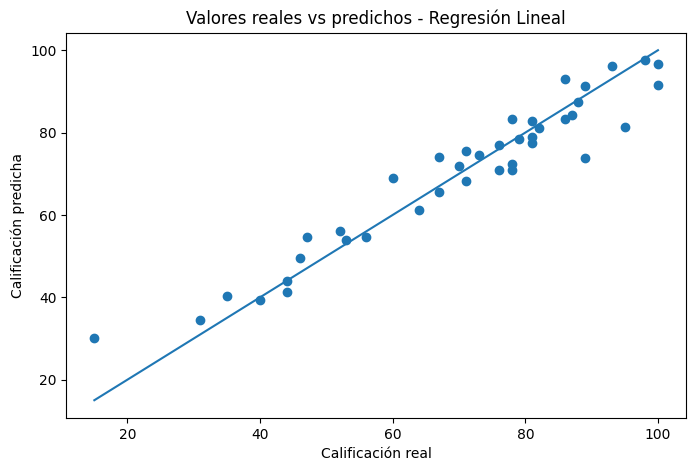

In [ ]:
nombre_mejor_regresion = mejor_regresion["Algoritmo"]

predicciones_mejor_regresion = modelos_regresion[
    nombre_mejor_regresion
]

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_regresion,
    predicciones_mejor_regresion
)

plt.plot(
    [y_test_regresion.min(), y_test_regresion.max()],
    [y_test_regresion.min(), y_test_regresion.max()]
)

plt.xlabel("Calificación real")
plt.ylabel("Calificación predicha")
plt.title(
    f"Valores reales vs predichos - {nombre_mejor_regresion}"
)

plt.show()

# Fase 6. Optimización de los modelos

In [ ]:
# Importar herramientas de optimización

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# Optimizar Regresión Logística

In [ ]:
pipeline_logistico = Pipeline([
    ("escalador", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000))
])

parametros_logistico = {
    "modelo__C": [0.01, 0.1, 1, 10, 100],
    "modelo__solver": ["liblinear", "lbfgs"]
}

busqueda_logistica = GridSearchCV(
    estimator=pipeline_logistico,
    param_grid=parametros_logistico,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

busqueda_logistica.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

mejor_logistico = busqueda_logistica.best_estimator_

print("Mejores parámetros de Regresión Logística:")
print(busqueda_logistica.best_params_)
print("Mejor F1 en validación cruzada:")
print(round(busqueda_logistica.best_score_, 4))

Mejores parámetros de Regresión Logística:
{'modelo__C': 0.1, 'modelo__solver': 'lbfgs'}
Mejor F1 en validación cruzada:
0.9291


In [ ]:
# Optimizar Árbol de Decisión para clasificación

In [ ]:
parametros_arbol_clasificacion = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

busqueda_arbol_clasificacion = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parametros_arbol_clasificacion,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

busqueda_arbol_clasificacion.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

mejor_arbol_clasificacion = busqueda_arbol_clasificacion.best_estimator_

print("Mejores parámetros del Árbol de Decisión:")
print(busqueda_arbol_clasificacion.best_params_)
print("Mejor F1 en validación cruzada:")
print(round(busqueda_arbol_clasificacion.best_score_, 4))

Mejores parámetros del Árbol de Decisión:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1 en validación cruzada:
0.915


In [ ]:
# Optimizar Random Forest para clasificación

In [ ]:
parametros_random_forest_clasificacion = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

busqueda_random_forest_clasificacion = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parametros_random_forest_clasificacion,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

busqueda_random_forest_clasificacion.fit(
    X_train_clasificacion,
    y_train_clasificacion
)

mejor_random_forest_clasificacion = (
    busqueda_random_forest_clasificacion.best_estimator_
)

print("Mejores parámetros de Random Forest:")
print(busqueda_random_forest_clasificacion.best_params_)
print("Mejor F1 en validación cruzada:")
print(round(busqueda_random_forest_clasificacion.best_score_, 4))

Mejores parámetros de Random Forest:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1 en validación cruzada:
0.9334


In [ ]:
# Generar nuevas predicciones de clasificación

In [ ]:
pred_logistico_optimizado = mejor_logistico.predict(
    X_test_clasificacion
)

pred_arbol_clasificacion_optimizado = (
    mejor_arbol_clasificacion.predict(
        X_test_clasificacion
    )
)

pred_random_forest_clasificacion_optimizado = (
    mejor_random_forest_clasificacion.predict(
        X_test_clasificacion
    )
)

print("Predicciones optimizadas de clasificación generadas.")

Predicciones optimizadas de clasificación generadas.


In [ ]:
# Comparar clasificación antes y después

In [ ]:
comparacion_clasificacion_optimizacion = pd.DataFrame([
    {
        "Modelo": "Regresión Logística",
        "Accuracy antes": accuracy_score(
            y_test_clasificacion,
            pred_logistico
        ),
        "Accuracy después": accuracy_score(
            y_test_clasificacion,
            pred_logistico_optimizado
        ),
        "F1 antes": f1_score(
            y_test_clasificacion,
            pred_logistico
        ),
        "F1 después": f1_score(
            y_test_clasificacion,
            pred_logistico_optimizado
        )
    },
    {
        "Modelo": "Árbol de Decisión",
        "Accuracy antes": accuracy_score(
            y_test_clasificacion,
            pred_arbol_clasificacion
        ),
        "Accuracy después": accuracy_score(
            y_test_clasificacion,
            pred_arbol_clasificacion_optimizado
        ),
        "F1 antes": f1_score(
            y_test_clasificacion,
            pred_arbol_clasificacion
        ),
        "F1 después": f1_score(
            y_test_clasificacion,
            pred_arbol_clasificacion_optimizado
        )
    },
    {
        "Modelo": "Random Forest",
        "Accuracy antes": accuracy_score(
            y_test_clasificacion,
            pred_random_forest_clasificacion
        ),
        "Accuracy después": accuracy_score(
            y_test_clasificacion,
            pred_random_forest_clasificacion_optimizado
        ),
        "F1 antes": f1_score(
            y_test_clasificacion,
            pred_random_forest_clasificacion
        ),
        "F1 después": f1_score(
            y_test_clasificacion,
            pred_random_forest_clasificacion_optimizado
        )
    }
])

columnas_clasificacion = [
    "Accuracy antes",
    "Accuracy después",
    "F1 antes",
    "F1 después"
]

comparacion_clasificacion_optimizacion[
    columnas_clasificacion
] = comparacion_clasificacion_optimizacion[
    columnas_clasificacion
].round(4)

display(comparacion_clasificacion_optimizacion)

,Modelo,Accuracy antes,Accuracy después,F1 antes,F1 después
0,Regresión Logística,0.925,0.825,0.9362,0.8444
1,Árbol de Decisión,0.900,0.900,0.9091,0.9091
2,Random Forest,0.900,0.900,0.9130,0.9130


In [ ]:
# Optimizar Decision Tree Regressor

In [ ]:
parametros_arbol_regresion = {
    "criterion": ["squared_error", "absolute_error"],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

busqueda_arbol_regresion = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=parametros_arbol_regresion,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

busqueda_arbol_regresion.fit(
    X_train_regresion,
    y_train_regresion
)

mejor_arbol_regresion = busqueda_arbol_regresion.best_estimator_

print("Mejores parámetros del Árbol de Regresión:")
print(busqueda_arbol_regresion.best_params_)
print("Mejor RMSE en validación cruzada:")
print(round(-busqueda_arbol_regresion.best_score_, 4))

Mejores parámetros del Árbol de Regresión:
{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Mejor RMSE en validación cruzada:
6.8721


In [ ]:
# Optimizar Random Forest Regressor

In [ ]:
parametros_random_forest_regresion = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

busqueda_random_forest_regresion = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=parametros_random_forest_regresion,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

busqueda_random_forest_regresion.fit(
    X_train_regresion,
    y_train_regresion
)

mejor_random_forest_regresion = (
    busqueda_random_forest_regresion.best_estimator_
)

print("Mejores parámetros de Random Forest Regressor:")
print(busqueda_random_forest_regresion.best_params_)
print("Mejor RMSE en validación cruzada:")
print(round(-busqueda_random_forest_regresion.best_score_, 4))

Mejores parámetros de Random Forest Regressor:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Mejor RMSE en validación cruzada:
5.7697


In [ ]:
# Generar nuevas predicciones de regresión

In [ ]:
pred_arbol_regresion_optimizado = (
    mejor_arbol_regresion.predict(
        X_test_regresion
    )
)

pred_random_forest_regresion_optimizado = (
    mejor_random_forest_regresion.predict(
        X_test_regresion
    )
)

print("Predicciones optimizadas de regresión generadas.")

Predicciones optimizadas de regresión generadas.


In [ ]:
# Comparar regresión antes y después

In [ ]:
def calcular_metricas_regresion(valores_reales, predicciones):
    mae = mean_absolute_error(
        valores_reales,
        predicciones
    )

    mse = mean_squared_error(
        valores_reales,
        predicciones
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        valores_reales,
        predicciones
    )

    return mae, mse, rmse, r2

In [ ]:
mae_lineal, mse_lineal, rmse_lineal, r2_lineal = (
    calcular_metricas_regresion(
        y_test_regresion,
        pred_lineal
    )
)

mae_arbol_antes, mse_arbol_antes, rmse_arbol_antes, r2_arbol_antes = (
    calcular_metricas_regresion(
        y_test_regresion,
        pred_arbol_regresion
    )
)

mae_arbol_despues, mse_arbol_despues, rmse_arbol_despues, r2_arbol_despues = (
    calcular_metricas_regresion(
        y_test_regresion,
        pred_arbol_regresion_optimizado
    )
)

mae_rf_antes, mse_rf_antes, rmse_rf_antes, r2_rf_antes = (
    calcular_metricas_regresion(
        y_test_regresion,
        pred_random_forest_regresion
    )
)

mae_rf_despues, mse_rf_despues, rmse_rf_despues, r2_rf_despues = (
    calcular_metricas_regresion(
        y_test_regresion,
        pred_random_forest_regresion_optimizado
    )
)

In [ ]:
comparacion_regresion_optimizacion = pd.DataFrame([
    {
        "Modelo": "Regresión Lineal",
        "RMSE antes": rmse_lineal,
        "RMSE después": rmse_lineal,
        "R² antes": r2_lineal,
        "R² después": r2_lineal
    },
    {
        "Modelo": "Árbol de Decisión",
        "RMSE antes": rmse_arbol_antes,
        "RMSE después": rmse_arbol_despues,
        "R² antes": r2_arbol_antes,
        "R² después": r2_arbol_despues
    },
    {
        "Modelo": "Random Forest",
        "RMSE antes": rmse_rf_antes,
        "RMSE después": rmse_rf_despues,
        "R² antes": r2_rf_antes,
        "R² después": r2_rf_despues
    }
])

columnas_regresion = [
    "RMSE antes",
    "RMSE después",
    "R² antes",
    "R² después"
]

comparacion_regresion_optimizacion[
    columnas_regresion
] = comparacion_regresion_optimizacion[
    columnas_regresion
].round(4)

display(comparacion_regresion_optimizacion)

,Modelo,RMSE antes,RMSE después,R² antes,R² después
0,Regresión Lineal,5.6475,5.6475,0.9229,0.9229
1,Árbol de Decisión,7.5614,7.8778,0.8617,0.8499
2,Random Forest,7.1082,7.3552,0.8778,0.8692


In [ ]:
# Comparar entrenamiento y prueba en clasificación

In [ ]:
modelos_optimizados_clasificacion = {
    "Regresión Logística": mejor_logistico,
    "Árbol de Decisión": mejor_arbol_clasificacion,
    "Random Forest": mejor_random_forest_clasificacion
}

sobreajuste_clasificacion = []

for nombre, modelo in modelos_optimizados_clasificacion.items():
    pred_train = modelo.predict(
        X_train_clasificacion
    )

    pred_test = modelo.predict(
        X_test_clasificacion
    )

    accuracy_train = accuracy_score(
        y_train_clasificacion,
        pred_train
    )

    accuracy_test = accuracy_score(
        y_test_clasificacion,
        pred_test
    )

    sobreajuste_clasificacion.append({
        "Modelo": nombre,
        "Accuracy entrenamiento": accuracy_train,
        "Accuracy prueba": accuracy_test,
        "Diferencia": accuracy_train - accuracy_test
    })

tabla_sobreajuste_clasificacion = pd.DataFrame(
    sobreajuste_clasificacion
)

columnas = [
    "Accuracy entrenamiento",
    "Accuracy prueba",
    "Diferencia"
]

tabla_sobreajuste_clasificacion[columnas] = (
    tabla_sobreajuste_clasificacion[columnas].round(4)
)

display(tabla_sobreajuste_clasificacion)

,Modelo,Accuracy entrenamiento,Accuracy prueba,Diferencia
0,Regresión Logística,0.9125,0.825,0.0875
1,Árbol de Decisión,0.9875,0.900,0.0875
2,Random Forest,0.9688,0.900,0.0687


In [ ]:
# Comparar entrenamiento y prueba en regresión

In [ ]:
modelos_evaluacion_regresion = {
    "Regresión Lineal": modelo_lineal,
    "Árbol de Decisión optimizado": mejor_arbol_regresion,
    "Random Forest optimizado": mejor_random_forest_regresion
}

sobreajuste_regresion = []

for nombre, modelo in modelos_evaluacion_regresion.items():
    pred_train = modelo.predict(
        X_train_regresion
    )

    pred_test = modelo.predict(
        X_test_regresion
    )

    r2_train = r2_score(
        y_train_regresion,
        pred_train
    )

    r2_test = r2_score(
        y_test_regresion,
        pred_test
    )

    sobreajuste_regresion.append({
        "Modelo": nombre,
        "R² entrenamiento": r2_train,
        "R² prueba": r2_test,
        "Diferencia": r2_train - r2_test
    })

tabla_sobreajuste_regresion = pd.DataFrame(
    sobreajuste_regresion
)

columnas = [
    "R² entrenamiento",
    "R² prueba",
    "Diferencia"
]

tabla_sobreajuste_regresion[columnas] = (
    tabla_sobreajuste_regresion[columnas].round(4)
)

display(tabla_sobreajuste_regresion)

,Modelo,R² entrenamiento,R² prueba,Diferencia
0,Regresión Lineal,0.9026,0.9229,-0.0203
1,Árbol de Decisión optimizado,0.9336,0.8499,0.0837
2,Random Forest optimizado,0.9480,0.8692,0.0788


# Fase 7. Resultados finales

In [ ]:
# Definir los modelos finales

In [ ]:
modelo_final_clasificacion = modelo_logistico
modelo_final_regresion = modelo_lineal

print("Modelo final de clasificación: Regresión Logística")
print("Modelo final de regresión: Regresión Lineal")

Modelo final de clasificación: Regresión Logística
Modelo final de regresión: Regresión Lineal


In [ ]:
# Crear la tabla final de modelos

In [ ]:
tabla_modelos_finales = pd.DataFrame([
    {
        "Problema": "Clasificación",
        "Modelo seleccionado": "Regresión Logística",
        "Métrica principal": "F1-score",
        "Resultado": 0.9362,
        "Métrica adicional": "Accuracy",
        "Resultado adicional": 0.9250
    },
    {
        "Problema": "Regresión",
        "Modelo seleccionado": "Regresión Lineal",
        "Métrica principal": "RMSE",
        "Resultado": 5.6475,
        "Métrica adicional": "R²",
        "Resultado adicional": 0.9229
    }
])

display(tabla_modelos_finales)

,Problema,Modelo seleccionado,Métrica principal,Resultado,Métrica adicional,Resultado adicional
0,Clasificación,Regresión Logística,F1-score,0.9362,Accuracy,0.9250
1,Regresión,Regresión Lineal,RMSE,5.6475,R²,0.9229


Análisis de variables importantes

In [ ]:
# Importar la herramienta

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
# Importancia de variables en clasificación

In [ ]:
importancia_clasificacion = permutation_importance(
    modelo_final_clasificacion,
    X_test_clasificacion,
    y_test_clasificacion,
    scoring="f1",
    n_repeats=30,
    random_state=42
)

tabla_importancia_clasificacion = pd.DataFrame({
    "Variable": variables_entrada,
    "Importancia": importancia_clasificacion.importances_mean
}).sort_values(
    by="Importancia",
    ascending=False
).reset_index(drop=True)

tabla_importancia_clasificacion["Importancia"] = (
    tabla_importancia_clasificacion["Importancia"].round(4)
)

display(tabla_importancia_clasificacion)

,Variable,Importancia
0,Promedio_Parcial,0.1434
1,Tareas,0.0443
2,Asistencia,0.0389
3,Horas_Estudio,0.0308
4,Accesos_Moodle,0.0167


In [ ]:
# Gráfica de clasificación

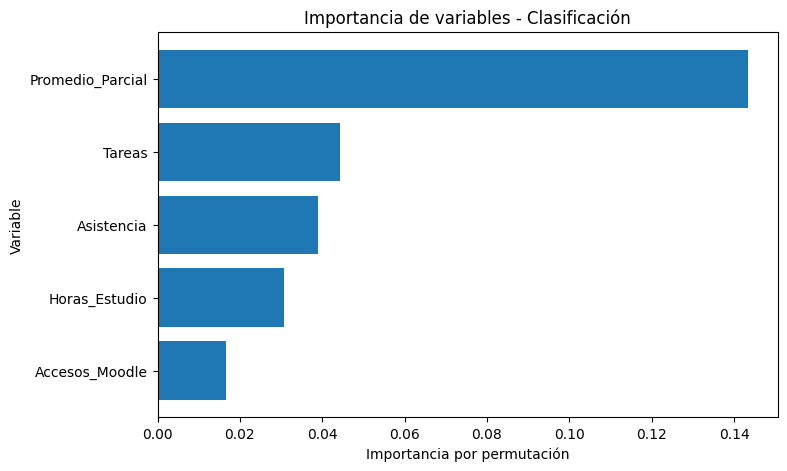

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    tabla_importancia_clasificacion["Variable"],
    tabla_importancia_clasificacion["Importancia"]
)

plt.xlabel("Importancia por permutación")
plt.ylabel("Variable")
plt.title("Importancia de variables - Clasificación")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Importancia de variables en regresión

In [ ]:
importancia_regresion = permutation_importance(
    modelo_final_regresion,
    X_test_regresion,
    y_test_regresion,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=42
)

tabla_importancia_regresion = pd.DataFrame({
    "Variable": variables_entrada,
    "Importancia": importancia_regresion.importances_mean
}).sort_values(
    by="Importancia",
    ascending=False
).reset_index(drop=True)

tabla_importancia_regresion["Importancia"] = (
    tabla_importancia_regresion["Importancia"].round(4)
)

display(tabla_importancia_regresion)

,Variable,Importancia
0,Promedio_Parcial,7.4711
1,Tareas,3.0566
2,Asistencia,2.7547
3,Horas_Estudio,1.7662
4,Accesos_Moodle,1.1549


In [ ]:
# Gráfica de regresión

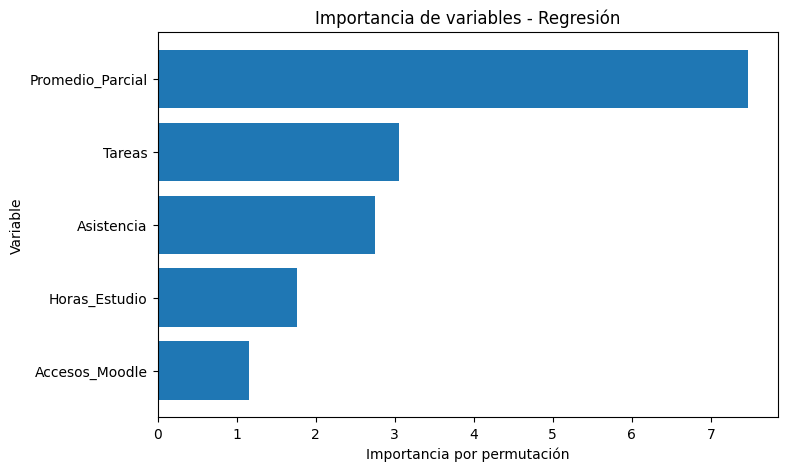

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    tabla_importancia_regresion["Variable"],
    tabla_importancia_regresion["Importancia"]
)

plt.xlabel("Importancia por permutación")
plt.ylabel("Variable")
plt.title("Importancia de variables - Regresión")
plt.gca().invert_yaxis()
plt.show()

Predicciones finales de ejemplo

In [ ]:
# Ejemplos del modelo de clasificación

In [ ]:
probabilidad_aprobar = modelo_final_clasificacion.predict_proba(
    X_test_clasificacion
)[:, 1]

probabilidad_reprobar = 1 - probabilidad_aprobar

prediccion_final_clasificacion = modelo_final_clasificacion.predict(
    X_test_clasificacion
)

ejemplos_clasificacion = X_test_clasificacion.copy()

ejemplos_clasificacion["Resultado_real"] = (
    y_test_clasificacion
    .map({1: "Aprueba", 0: "Reprueba"})
    .values
)

ejemplos_clasificacion["Prediccion"] = pd.Series(
    prediccion_final_clasificacion
).map({
    1: "Aprueba",
    0: "Reprueba"
}).values

ejemplos_clasificacion["Probabilidad_Reprobar"] = (
    probabilidad_reprobar * 100
).round(2)

display(
    ejemplos_clasificacion[
        [
            "Promedio_Parcial",
            "Asistencia",
            "Tareas",
            "Resultado_real",
            "Prediccion",
            "Probabilidad_Reprobar"
        ]
    ].head(10)
)

,Promedio_Parcial,Asistencia,Tareas,Resultado_real,Prediccion,Probabilidad_Reprobar
150,26,53,0,Reprueba,Reprueba,100.00
0,92,81,9,Aprueba,Aprueba,0.02
70,54,78,9,Aprueba,Aprueba,34.56
54,88,93,10,Aprueba,Aprueba,0.00
179,54,79,5,Reprueba,Reprueba,96.98
16,51,75,0,Reprueba,Reprueba,100.00
10,76,100,10,Aprueba,Aprueba,0.00
178,71,82,7,Aprueba,Aprueba,48.64
99,50,67,3,Reprueba,Reprueba,99.85
131,59,64,8,Reprueba,Reprueba,89.02


In [ ]:
# Estudiantes con mayor riesgo

In [ ]:
estudiantes_riesgo = ejemplos_clasificacion.sort_values(
    by="Probabilidad_Reprobar",
    ascending=False
)

display(
    estudiantes_riesgo[
        [
            "Promedio_Parcial",
            "Asistencia",
            "Horas_Estudio",
            "Accesos_Moodle",
            "Tareas",
            "Prediccion",
            "Probabilidad_Reprobar"
        ]
    ].head(10)
)

,Promedio_Parcial,Asistencia,Horas_Estudio,Accesos_Moodle,Tareas,Prediccion,Probabilidad_Reprobar
150,26,53,0.0,2,0,Reprueba,100.00
16,51,75,0.3,0,0,Reprueba,100.00
43,37,64,0.0,4,4,Reprueba,100.00
62,23,51,0.0,0,2,Reprueba,100.00
182,32,62,0.0,0,4,Reprueba,100.00
6,52,62,3.1,17,2,Reprueba,99.97
148,52,74,2.6,7,3,Reprueba,99.91
99,50,67,3.0,30,3,Reprueba,99.85
58,45,84,3.0,21,4,Reprueba,99.56
59,47,78,6.1,2,6,Reprueba,99.22


In [ ]:
# Ejemplos del modelo de regresión

In [ ]:
prediccion_final_regresion = modelo_final_regresion.predict(
    X_test_regresion
)

ejemplos_regresion = X_test_regresion.copy()

ejemplos_regresion["Calificacion_real"] = (
    y_test_regresion.values
)

ejemplos_regresion["Calificacion_predicha"] = (
    prediccion_final_regresion.round(2)
)

ejemplos_regresion["Error_absoluto"] = (
    abs(
        ejemplos_regresion["Calificacion_real"]
        - ejemplos_regresion["Calificacion_predicha"]
    ).round(2)
)

display(
    ejemplos_regresion[
        [
            "Promedio_Parcial",
            "Asistencia",
            "Tareas",
            "Calificacion_real",
            "Calificacion_predicha",
            "Error_absoluto"
        ]
    ].head(10)
)

,Promedio_Parcial,Asistencia,Tareas,Calificacion_real,Calificacion_predicha,Error_absoluto
95,35,50,3,44,41.26,2.74
15,57,85,10,81,77.51,3.49
30,77,97,7,88,87.35,0.65
158,48,78,5,64,61.13,2.87
128,70,87,10,81,82.70,1.70
115,24,54,3,40,39.35,0.65
69,96,100,10,98,97.67,0.33
170,82,91,9,89,91.30,2.30
174,49,87,7,71,68.24,2.76
45,62,71,7,60,68.96,8.96
